In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# Configure plotting defaults
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "font.size": 12
})

In [2]:
def choose_action_eps(Q_table, current_state, eps, action_space):
    """
    Epsilon-greedy action selection:
    - With probability eps → random action
    - Otherwise → greedy action
    """
    if np.random.random() < eps:
        action = np.random.choice(action_space.n)
    else:
        action = int(np.argmax(Q_table[current_state]))
    
    return action


def apply_seed(seed_value):
    """
    Initialize NumPy random seed for reproducibility.
    """
    np.random.seed(seed_value)

In [3]:
def train_sarsa(
    num_episodes=500,
    alpha=0.5,
    gamma=0.99,
    epsilon_start=0.1,
    epsilon_min=0.01,
    epsilon_decay=1.0,
    seed=0,
):
    """
    SARSA (on-policy TD control) for CliffWalking-v0.
    Returns learned Q-table and episodic rewards.
    """
    apply_seed(seed)
    env = gym.make("CliffWalking-v1")

    nS = env.observation_space.n
    nA = env.action_space.n

    Q_table = np.zeros((nS, nA))
    rewards_log = []

    epsilon = epsilon_start

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0.0

        # initial action
        action = choose_action_eps(Q_table, state, epsilon, env.action_space)

        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            if done:
                # terminal update (no bootstrap)
                Q_table[state, action] += alpha * (reward - Q_table[state, action])
                break

            # choose next action (on-policy)
            next_action = choose_action_eps(Q_table, next_state, epsilon, env.action_space)

            # SARSA update
            target = reward + gamma * Q_table[next_state, next_action]
            Q_table[state, action] += alpha * (target - Q_table[state, action])

            state, action = next_state, next_action

        rewards_log.append(total_reward)

        # decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q_table, np.array(rewards_log)

In [4]:
def train_q_learning(
    num_episodes=500,
    alpha=0.5,
    gamma=0.99,
    epsilon_start=0.1,
    epsilon_min=0.01,
    epsilon_decay=1.0,
    seed=0,
):
    """
    Q-learning (off-policy TD control) for CliffWalking-v0.
    Returns learned Q-table and episodic rewards.
    """
    apply_seed(seed)
    env = gym.make("CliffWalking-v1")

    nS = env.observation_space.n
    nA = env.action_space.n

    Q_table = np.zeros((nS, nA))
    rewards_log = []

    epsilon = epsilon_start

    for ep in range(num_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0.0

        while True:
            # behavior policy (ε-greedy)
            action = choose_action_eps(Q_table, state, epsilon, env.action_space)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            if done:
                target = reward
            else:
                best_next_value = np.max(Q_table[next_state])
                target = reward + gamma * best_next_value

            # Q-learning update
            Q_table[state, action] += alpha * (target - Q_table[state, action])

            if done:
                break

            state = next_state

        rewards_log.append(total_reward)

        # decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q_table, np.array(rewards_log)

In [5]:
def run_multi_seed_experiment(
    algo="sarsa",
    num_seeds=30,
    num_episodes=500,
    alpha=0.5,
    gamma=0.99,
    epsilon_start=0.1,
    epsilon_min=0.01,
    epsilon_decay=1.0,
):
    """
    Execute multiple runs (different seeds) for SARSA or Q-learning
    and collect episode returns.

    Returns:
        returns_matrix: shape (num_seeds, num_episodes)
        last_Q: Q-table from final run
    """
    returns_collection = []
    last_Q = None

    # normalize algorithm name once
    algo_name = algo.lower()

    for s in range(num_seeds):
        if algo_name == "sarsa":
            Q_table, ep_returns = train_sarsa(
                num_episodes=num_episodes,
                alpha=alpha,
                gamma=gamma,
                epsilon_start=epsilon_start,
                epsilon_min=epsilon_min,
                epsilon_decay=epsilon_decay,
                seed=s,
            )

        elif algo_name in ("q_learning", "q-learning", "qlearning"):
            Q_table, ep_returns = train_q_learning(
                num_episodes=num_episodes,
                alpha=alpha,
                gamma=gamma,
                epsilon_start=epsilon_start,
                epsilon_min=epsilon_min,
                epsilon_decay=epsilon_decay,
                seed=s,
            )

        else:
            raise ValueError("Invalid algorithm choice: use 'sarsa' or 'q_learning'")

        returns_collection.append(ep_returns)
        last_Q = Q_table  # keep updating (final one remains)

    # convert list → array
    returns_matrix = np.vstack(returns_collection)

    return returns_matrix, last_Q

In [6]:
def draw_learning_curve_ci(returns_array, name, color=None):
    """
    returns_array: shape (num_runs, num_episodes)
    """
    n_runs, n_eps = returns_array.shape

    avg_curve = np.mean(returns_array, axis=0)
    spread = np.std(returns_array, axis=0, ddof=1)

    conf_interval = 1.96 * spread / np.sqrt(n_runs)

    x_axis = np.arange(n_eps)

    plt.plot(x_axis, avg_curve, label=name)
    plt.fill_between(
        x_axis,
        avg_curve - conf_interval,
        avg_curve + conf_interval,
        alpha=0.2
    )


def compare_algorithms_plot(sarsa_data, qlearn_data):
    plt.figure(figsize=(12, 5))

    draw_learning_curve_ci(sarsa_data, name="SARSA")
    draw_learning_curve_ci(qlearn_data, name="Q-Learning")

    plt.xlabel("Episodes")
    plt.ylabel("Episode Return")
    plt.title("SARSA vs Q-Learning Performance (95% CI)")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Starting SARSA runs across 30 seeds...
Starting Q-learning runs across 30 seeds...


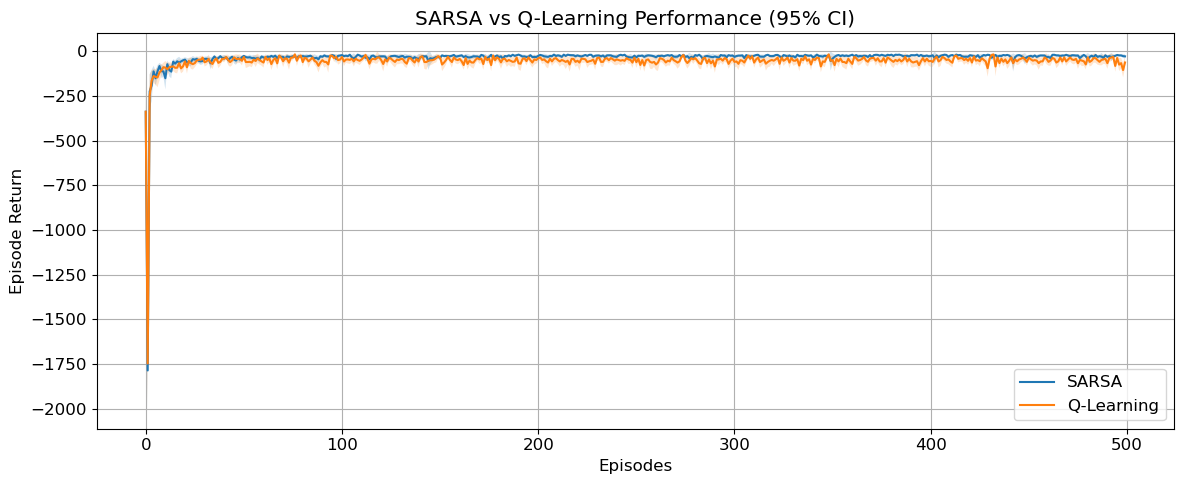

In [7]:
TOTAL_RUNS = 30
EPISODE_COUNT = 500

# Default hyperparameters
LR = 0.5
DISCOUNT = 0.99
EPS_INIT = 0.1
EPS_LOWER = 0.01
EPS_RATE = 1.0

print(f"Starting SARSA runs across {TOTAL_RUNS} seeds...")
sarsa_data, sarsa_qtable = run_multi_seed_experiment(
    algo="sarsa",
    num_seeds=TOTAL_RUNS,
    num_episodes=EPISODE_COUNT,
    alpha=LR,
    gamma=DISCOUNT,
    epsilon_start=EPS_INIT,
    epsilon_min=EPS_LOWER,
    epsilon_decay=EPS_RATE,
)

print(f"Starting Q-learning runs across {TOTAL_RUNS} seeds...")
qlearn_data, qlearn_qtable = run_multi_seed_experiment(
    algo="q_learning",
    num_seeds=TOTAL_RUNS,
    num_episodes=EPISODE_COUNT,
    alpha=LR,
    gamma=DISCOUNT,
    epsilon_start=EPS_INIT,
    epsilon_min=EPS_LOWER,
    epsilon_decay=EPS_RATE,
)

# Plot comparison
compare_algorithms_plot(sarsa_data, qlearn_data)

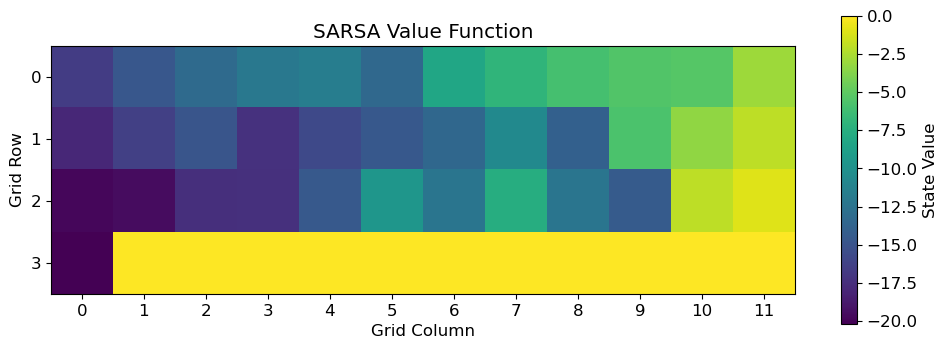

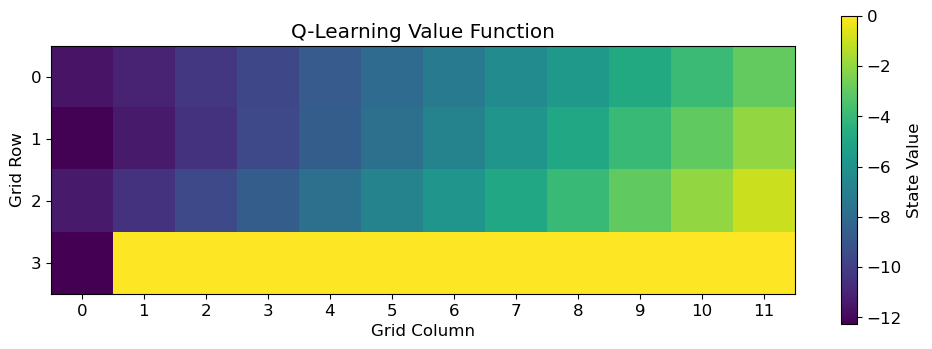

In [ ]:
def display_state_value_map(Q_table, heading="State Value Heatmap"):
    """
    Computes V(s) = max_a Q(s,a) and visualizes it as a grid (4x12).
    """
    total_states, total_actions = Q_table.shape

    if total_states != 48:
        raise ValueError("Expected 48 states for CliffWalking grid (4x12).")

    # derive value function
    state_values = np.max(Q_table, axis=1)
    grid_values = state_values.reshape(4, 12)

    plt.figure(figsize=(12, 4))
    img = plt.imshow(grid_values, origin="upper", interpolation="nearest")

    plt.colorbar(img, label="State Value")

    plt.title(heading)
    plt.xlabel("Grid Column")
    plt.ylabel("Grid Row")

    plt.xticks(np.arange(12))
    plt.yticks(np.arange(4))

    plt.show()



display_state_value_map(sarsa_qtable, heading="SARSA Value Function")
display_state_value_map(qlearn_qtable, heading="Q-Learning Value Function")

→ | → | → | → | → | → | → | → | → | → | → | ↓
→ | → | ↑ | ↑ | ↑ | → | → | ↑ | ↑ | → | → | ↓
↑ | ↑ | → | ↑ | ↑ | ← | ↑ | ← | ↑ | ↑ | → | ↓
↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑


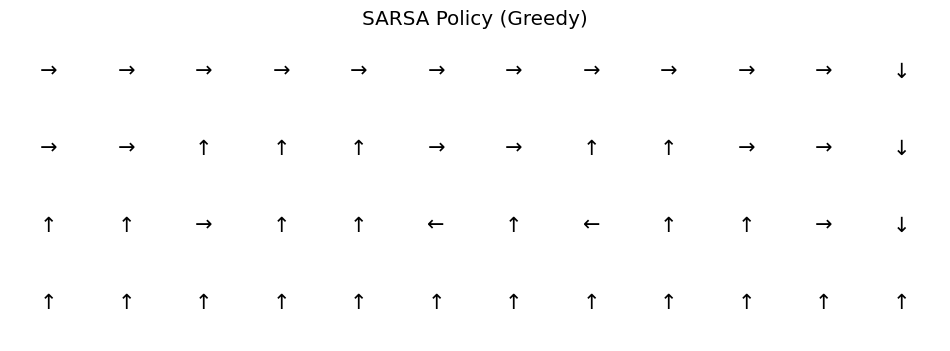

→ | → | → | → | ← | → | → | ↑ | ↓ | → | → | →
→ | → | ↓ | → | ↓ | → | → | ↓ | ↓ | ↓ | ↓ | ↓
→ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↑


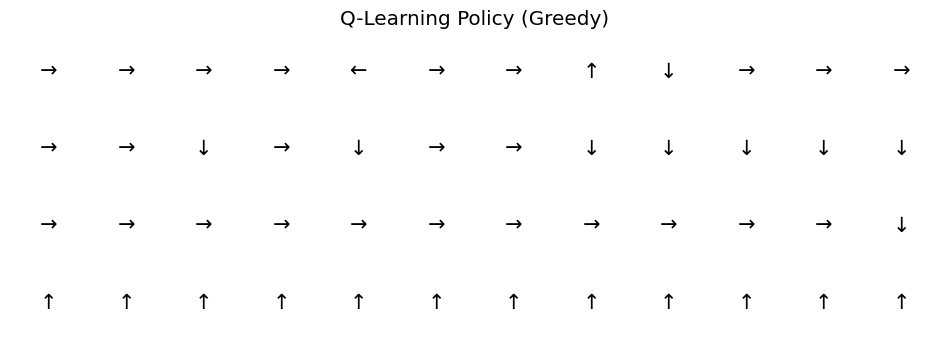

In [ ]:
def visualize_policy_grid(Q_table, heading="Greedy Policy Visualization"):
    """
    Display greedy actions (argmax over Q) as directional arrows
    on the 4x12 CliffWalking grid.
    """
    nS, nA = Q_table.shape

    if nS != 48:
        raise ValueError("Expected 48 states for CliffWalking (4x12 grid).")

    # compute greedy actions
    greedy_actions = np.argmax(Q_table, axis=1)
    grid_policy = greedy_actions.reshape(4, 12)

    arrow_map = {
        0: "↑",
        1: "→",
        2: "↓",
        3: "←"
    }

    plt.figure(figsize=(12, 4))
    plt.title(heading)
    plt.axis("off")

    # print textual grid (slightly different style)
    for i in range(4):
        line = [arrow_map[int(grid_policy[i, j])] for j in range(12)]
        print(" | ".join(line))

    # draw arrows on grid
    for i in range(4):
        for j in range(12):
            arrow = arrow_map[int(grid_policy[i, j])]
            plt.text(j + 0.5, i + 0.5, arrow,
                     ha="center", va="center", fontsize=15)

    plt.xlim(0, 12)
    plt.ylim(4, 0)
    plt.grid(True)

    plt.show()


visualize_policy_grid(sarsa_qtable, heading="SARSA Policy (Greedy)")
visualize_policy_grid(qlearn_qtable, heading="Q-Learning Policy (Greedy)")

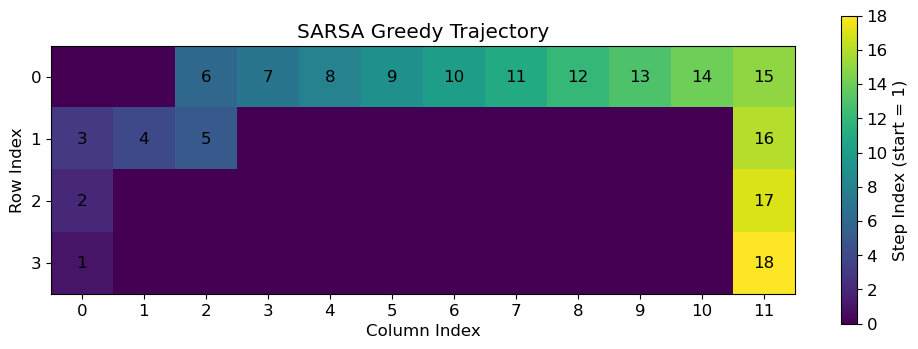

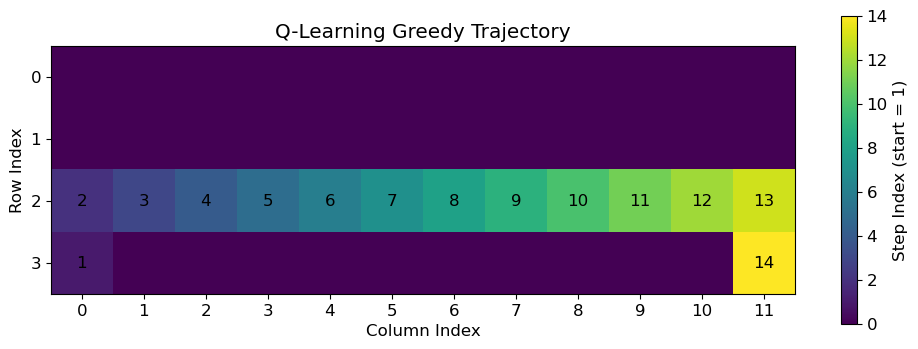

In [10]:
def extract_greedy_path(Q_table, max_steps=100):
    """
    Execute a deterministic (greedy) policy from Q_table
    and return the sequence of visited states.
    """
    env = gym.make("CliffWalking-v1")

    current_state, _ = env.reset()
    path = [current_state]

    for _ in range(max_steps):
        action = int(np.argmax(Q_table[current_state]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        path.append(next_state)

        if terminated or truncated:
            break

        current_state = next_state

    env.close()
    return path


def visualize_path_grid(state_sequence, heading="Grid Trajectory"):
    """
    Display trajectory progression on the 4x12 grid.
    Each cell shows the visit order.
    """
    grid_map = np.zeros((4, 12))

    # assign visit indices
    for step_idx, s in enumerate(state_sequence):
        row, col = divmod(s, 12)
        grid_map[row, col] = step_idx + 1

    plt.figure(figsize=(12, 4))
    img = plt.imshow(grid_map, origin="upper", interpolation="nearest")

    plt.colorbar(img, label="Step Index (start = 1)")

    plt.title(heading)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")

    plt.xticks(np.arange(12))
    plt.yticks(np.arange(4))

    # annotate steps
    for i in range(4):
        for j in range(12):
            if grid_map[i, j] > 0:
                plt.text(j, i, int(grid_map[i, j]),
                         ha="center", va="center")

    plt.show()


# Example usage
sarsa_path = extract_greedy_path(sarsa_qtable)
qlearn_path = extract_greedy_path(qlearn_qtable)

visualize_path_grid(sarsa_path, heading="SARSA Greedy Trajectory")
visualize_path_grid(qlearn_path, heading="Q-Learning Greedy Trajectory")

## Performance Comparison

In this section, we compare SARSA and Q-learning using quantitative metrics.

### Metrics used

- Final performance:
  average return over the last N episodes

- Stability:
  standard deviation of returns over the last N episodes

- Learning speed:
  number of episodes required to reach a reward threshold

- Sample efficiency:
  total accumulated reward over all episodes (area under the learning curve)

### How metrics are computed

- Final performance is calculated as the mean of the last N episodes across all runs
- Stability is measured using standard deviation over the same set of episodes
- Learning speed is defined as the first episode where the average return exceeds a chosen threshold
- Sample efficiency is computed as the sum of average returns across episodes

### Interpretation

- Higher final performance indicates a better learned policy
- Lower stability (variance) indicates more consistent learning
- Fewer episodes to reach the threshold indicate faster learning
- Higher sample efficiency indicates better overall learning during training

In [11]:
import pandas as pd
import numpy as np

def compute_metrics(returns, last_k=50, threshold=-20):
    """
    Compute:
    - Final performance (mean over last_k episodes)
    - Stability (std over last_k episodes)
    - Learning speed (episodes to reach threshold)
    """
    # Final performance
    tail = returns[:, -last_k:]
    final_mean = np.mean(tail)
    final_std = np.std(tail, ddof=1)

    # Learning speed (episodes to reach threshold)
    mean_curve = np.mean(returns, axis=0)
    speed = len(mean_curve)  # default if threshold never reached

    for i, val in enumerate(mean_curve):
        if val >= threshold:
            speed = i
            break

    return final_mean, final_std, speed


# Compute metrics
sarsa_mean, sarsa_std, sarsa_speed = compute_metrics(sarsa_data)
q_mean, q_std, q_speed = compute_metrics(qlearn_data)


# Create table
comparison_df = pd.DataFrame({
    "Algorithm": ["SARSA", "Q-learning"],
    "Final Return (↑ better)": [sarsa_mean, q_mean],
    "Stability (↓ better)": [sarsa_std, q_std],
    "Episodes to Threshold (↓ better)": [sarsa_speed, q_speed]
})

print(comparison_df)

    Algorithm  Final Return (↑ better)  Stability (↓ better)  \
0       SARSA               -27.798000             31.503103   
1  Q-learning               -52.206667             72.252937   

   Episodes to Threshold (↓ better)  
0                               108  
1                                76  


In [12]:
def compute_sample_efficiency(returns):
    """
    Compute area under the learning curve (AUC).
    Higher is better.
    """
    mean_curve = np.mean(returns, axis=0)
    auc = np.sum(mean_curve)
    return auc


sarsa_auc = compute_sample_efficiency(sarsa_data)
q_auc = compute_sample_efficiency(qlearn_data)

print(f"SARSA AUC: {sarsa_auc:.2f}")
print(f"Q-learning AUC: {q_auc:.2f}")

SARSA AUC: -18335.23
Q-learning AUC: -28489.80


In [13]:
comparison_df["Sample Efficiency (AUC ↑ better)"] = [sarsa_auc, q_auc]

print(comparison_df)

    Algorithm  Final Return (↑ better)  Stability (↓ better)  \
0       SARSA               -27.798000             31.503103   
1  Q-learning               -52.206667             72.252937   

   Episodes to Threshold (↓ better)  Sample Efficiency (AUC ↑ better)  
0                               108                     -18335.233333  
1                                76                     -28489.800000  
